## Open notebook in:
| Colab                                 
:-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Nicolepcx/transformers-the-definitive-guide/blob/master/CH11/ch11_advanced_LoRA_fine_tuning.ipynb)                                             

# About This Notebook

This notebook gives you a high fidelity workflow for benchmarking instruction tuned models with [Unsloth](https://unsloth.ai/) and GRPO. You prepare two aligned datasets for supervised fine tuning and reinforcement learning, and apply multiple adapter strategies to the same base model. You then measure how each configuration impacts learning stability, reward improvement, and real token generation speed.

You work with four adapter families: LoRA, QLoRA, DoRA, and LoftQ. The notebook runs the same training pipeline for each variant so you can compare them under equal conditions. The supervised stage primes the model on structured reasoning traces. The GRPO stage optimizes the policy based on reward functions that check format correctness and final answer accuracy.

Treat this notebook like a lab. Change the model. Change the reward functions. Increase the dataset size. Swap OpenMath for your own domain specific data. The structure holds. Train, reinforce, measure. Make decisions based on evidence, not on assumptions.


__Note: Code is partially adapted from an Unsloth Example to run GRPO__

In [1]:
%%capture
import os
#os.environ["UNSLOTH_VLLM_STANDBY"] = "1" # [NEW] Extra 30% context lengths!

import os

# Either completely remove standby:
os.environ.pop("UNSLOTH_VLLM_STANDBY", None)

if "COLAB_" not in "".join(os.environ.keys()):
    # If you're not in Colab, just use pip install or uv pip install
    !pip install unsloth vllm
else:
    pass # For Colab / Kaggle, we need extra instructions hidden below \/

In [2]:
#@title Colab Extra Install { display-mode: "form" }
%%capture
import os
!pip install --upgrade -qqq uv
if "COLAB_" not in "".join(os.environ.keys()):
    # If you're not in Colab, just use pip install!
    !pip install unsloth vllm
else:
    try: import numpy, PIL; get_numpy = f"numpy=={numpy.__version__}"; get_pil = f"pillow=={PIL.__version__}"
    except: get_numpy = "numpy"; get_pil = "pillow"
    try: import subprocess; is_t4 = "Tesla T4" in str(subprocess.check_output(["nvidia-smi"]))
    except: is_t4 = False
    get_vllm, get_triton = ("vllm==0.9.2", "triton==3.2.0") if is_t4 else ("vllm==0.10.2", "triton")
    !uv pip install -qqq --upgrade \
        unsloth {get_vllm} {get_numpy} {get_pil} torchvision bitsandbytes xformers
    !uv pip install -qqq {get_triton}
!uv pip install transformers==4.56.2
!uv pip install --no-deps trl==0.22.2

# Imports


In [ ]:
import os
import gc
import torch
import pandas as pd
import numpy as np
import time
import re
import warnings
import logging
import matplotlib.pyplot as plt
from datasets import load_dataset, Dataset
from unsloth import FastLanguageModel
from trl import SFTTrainer, SFTConfig, GRPOTrainer, GRPOConfig
from transformers import logging as hf_logging
from peft import LoftQConfig

# SETUP & CONFIG

In [ ]:
warnings.filterwarnings('ignore')
hf_logging.set_verbosity_error()
logging.getLogger("unsloth").setLevel(logging.ERROR)
os.environ["WANDB_DISABLED"] = "true"
os.environ["UNSLOTH_VLLM_STANDBY"] = "0"

BRAND_COLOR = "#E51837"

# --- CONFIGURATION ---
MODEL_ID = "unsloth/Qwen3-4B-Base"
SFT_STEPS = 60
GRPO_STEPS = 200
GRPO_GENERATIONS = 4
DATASET_SIZE = 500

# DEFINITIONS

In [ ]:
reasoning_start, reasoning_end = "<start_working_out>", "<end_working_out>"
solution_start, solution_end = "<SOLUTION>", "</SOLUTION>"

system_prompt = (
    f"You are given a problem.\n"
    f"Think about the problem and provide your working out.\n"
    f"Place it between {reasoning_start} and {reasoning_end}.\n"
    f"Then, provide your solution between {solution_start}{solution_end}"
)

# Regex
match_format = re.compile(
    rf"{reasoning_end}.*?{solution_start}(.+?)(?:</SOLUTION>|$)",
    flags=re.MULTILINE | re.DOTALL
)

print(f"--- Preparing Expanded Datasets ({DATASET_SIZE} samples) ---")

def prepare_datasets():
    # SFT Data
    ds_sft = load_dataset("unsloth/OpenMathReasoning-mini", split="cot")
    ds_sft = ds_sft.select(range(DATASET_SIZE))

    def format_sft(x):
        thoughts = x["generated_solution"].replace("<think>", "").replace("</think>", "").strip()
        final_prompt = f"{reasoning_start}{thoughts}{reasoning_end}{solution_start}{x['expected_answer']}{solution_end}"
        return {
            "Messages": [
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": x["problem"]},
                {"role": "assistant", "content": final_prompt}
            ]
        }
    ds_sft = ds_sft.map(format_sft)

    # GRPO Data
    ds_grpo = load_dataset("open-r1/DAPO-Math-17k-Processed", "en", split="train")
    ds_grpo = ds_grpo.select(range(DATASET_SIZE))

    def format_grpo(x):
        return {
            "prompt": [
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": x["prompt"]}
            ],
            "answer": x["solution"]
        }
    ds_grpo = ds_grpo.map(format_grpo)

    return ds_sft, ds_grpo

sft_dataset, grpo_dataset = prepare_datasets()


# REWARD FUNCTIONS

In [ ]:
def match_format_reward(completions, **kwargs):
    scores = []
    for c in completions:
        scores.append(3.0 if match_format.search(c[0]["content"]) else 0.0)
    return scores

def check_answer_reward(prompts, completions, answer, **kwargs):
    scores = []
    for c, ans in zip(completions, answer):
        content = c[0]["content"]
        match = match_format.search(content)
        if match:
            if match.group(1).strip() == ans.strip():
                scores.append(5.0)
            else:
                scores.append(0.0)
        else:
            scores.append(0.0)
    return scores

# TRAINING ENGINE

In [ ]:
ADAPTERS = {
    "LoRA":  {"4bit": False, "peft": {"r": 16, "lora_alpha": 16, "target_modules": ["q_proj", "k_proj", "v_proj", "o_proj"]}},
    "QLoRA": {"4bit": True,  "peft": {"r": 16, "lora_alpha": 16, "target_modules": ["q_proj", "k_proj", "v_proj", "o_proj"]}},
    "DoRA":  {"4bit": False, "peft": {"r": 16, "lora_alpha": 16, "use_dora": True, "target_modules": ["q_proj", "k_proj", "v_proj", "o_proj"]}},
    "LoftQ": {"4bit": False, "peft": {"r": 16, "lora_alpha": 16, "target_modules": ["q_proj", "k_proj", "v_proj", "o_proj"], "init_lora_weights": "loftq", "loftq_config": LoftQConfig(loftq_bits=4, loftq_iter=1)}}
}

def run_scaled_variant(name, config):
    print(f"\n{'='*40}\n>>> Running High-Fidelity Benchmark: {name}\n{'='*40}")
    torch.cuda.empty_cache(); gc.collect()

    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=MODEL_ID,
        max_seq_length=1024,
        load_in_4bit=config["4bit"],
        fast_inference=False,
        gpu_memory_utilization=0.6
    )

    tokenizer.chat_template = (
        "{% if messages[0]['role'] == 'system' %}{{ messages[0]['content'] + eos_token }}{% endif %}"
        "{% for message in messages %}"
        "{% if message['role'] == 'user' %}{{ message['content'] }}{% elif message['role'] == 'assistant' %}{{ message['content'] + eos_token }}{% endif %}"
        "{% endfor %}"
        "{% if add_generation_prompt %}{{ '" + reasoning_start + "' }}{% endif %}"
    )

    model = FastLanguageModel.get_peft_model(model, **config["peft"])

    # SFT
    print(f"... SFT Priming ({SFT_STEPS} steps) ...")
    sft_data = sft_dataset.map(lambda x: {"text": tokenizer.apply_chat_template(x["Messages"], tokenize=False)})

    sft_trainer = SFTTrainer(
        model=model, tokenizer=tokenizer, train_dataset=sft_data, dataset_text_field="text",
        args=SFTConfig(
            output_dir=f"out_{name}",
            max_steps=SFT_STEPS,
            learning_rate=2e-4,
            logging_steps=5,
            optim="adamw_8bit",
            report_to="none",
            per_device_train_batch_size=4
        )
    )
    sft_trainer.train()
    sft_logs = [x['loss'] for x in sft_trainer.state.log_history if 'loss' in x]

    # GRPO
    print(f"... GRPO Optimization ({GRPO_STEPS} steps) ...")
    del sft_trainer; torch.cuda.empty_cache()

    grpo_args = GRPOConfig(
        output_dir=f"grpo_{name}",
        max_steps=GRPO_STEPS,
        per_device_train_batch_size=1,
        gradient_accumulation_steps=4,
        num_generations=GRPO_GENERATIONS,
        learning_rate=5e-6,
        report_to="none",
        use_vllm=False,
        logging_steps=5,
        max_prompt_length=256,
        max_completion_length=256
    )
    grpo_trainer = GRPOTrainer(
        model=model, processing_class=tokenizer, reward_funcs=[match_format_reward, check_answer_reward],
        args=grpo_args, train_dataset=grpo_dataset
    )
    grpo_trainer.train()

    grpo_logs = []
    for log in grpo_trainer.state.log_history:
        if 'reward' in log: grpo_logs.append(log['reward'])
        elif 'reward_mean' in log: grpo_logs.append(log['reward_mean'])

    # Inference
    FastLanguageModel.for_inference(model)
    msg = [{"role": "user", "content": "Calculate 25 * 4."}]
    inputs = tokenizer.apply_chat_template(msg, add_generation_prompt=True, return_tensors="pt", tokenize=True).to("cuda")
    start = time.time()
    out = model.generate(inputs, max_new_tokens=50, temperature=0.1)
    dur = time.time() - start
    tps = (len(out[0]) - inputs.shape[1]) / dur

    del model, tokenizer, grpo_trainer; gc.collect()

    return {"sft_loss": sft_logs, "grpo_reward": grpo_logs, "tps": tps}


# Run

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
INFO 11-30 15:11:03 [__init__.py:216] Automatically detected platform cuda.
🦥 Unsloth Zoo will now patch everything to make training faster!
--- Preparing Expanded Datasets (500 samples) ---


README.md:   0%|          | 0.00/603 [00:00<?, ?B/s]

data/cot-00000-of-00001.parquet:   0%|          | 0.00/106M [00:00<?, ?B/s]

Generating cot split:   0%|          | 0/19252 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

...

{'loss': 0.795, 'grad_norm': 0.10466352850198746, 'learning_rate': 0.00013333333333333334, 'epoch': 0.08}
{'loss': 0.7837, 'grad_norm': 0.12812483310699463, 'learning_rate': 0.00018888888888888888, 'epoch': 0.16}
{'loss': 0.6908, 'grad_norm': 0.16854621469974518, 'learning_rate': 0.00017037037037037037, 'epoch': 0.24}
{'loss': 0.6068, 'grad_norm': 0.15550318360328674, 'learning_rate': 0.00015185185185185185, 'epoch': 0.32}
{'loss': 0.5666, 'grad_norm': 0.1274106353521347, 'learning_rate': 0.00013333333333333334, 'epoch': 0.4}
{'loss': 0.6061, 'grad_norm': 0.12929804623126984, 'learning_rate': 0.00011481481481481482, 'epoch': 0.48}
{'loss': 0.5562, 'grad_norm': 0.11890935152769089, 'learning_rate': 9.62962962962963e-05, 'epoch': 0.56}
{'loss': 0.5249, 'grad_norm': 0.12758566439151764, 'learning_rate': 7.777777777777778e-05, 'epoch': 0.64}
{'loss': 0.5258, 'grad_norm': 0.11650846898555756, 'learning_rate': 5.925925925925926e-05, 'epoch': 0.72}
{'loss': 0.5764, 'grad_norm': 0.127972915768

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

... SFT Priming (60 steps) ...
{'loss': 0.7643, 'grad_norm': 0.2611980438232422, 'learning_rate': 0.00013333333333333334, 'epoch': 0.08}
{'loss': 0.7471, 'grad_norm': 0.21722128987312317, 'learning_rate': 0.00018888888888888888, 'epoch': 0.16}
{'loss': 0.665, 'grad_norm': 0.15616455674171448, 'learning_rate': 0.00017037037037037037, 'epoch': 0.24}
{'loss': 0.5912, 'grad_norm': 0.19929221272468567, 'learning_rate': 0.00015185185185185185, 'epoch': 0.32}
{'loss': 0.5414, 'grad_norm': 0.1336233913898468, 'learning_rate': 0.00013333333333333334, 'epoch': 0.4}
{'loss': 0.5776, 'grad_norm': 0.1354823261499405, 'learning_rate': 0.00011481481481481482, 'epoch': 0.48}
{'loss': 0.533, 'grad_norm': 0.12040834128856659, 'learning_rate': 9.62962962962963e-05, 'epoch': 0.56}
{'loss': 0.5044, 'grad_norm': 0.11833520233631134, 'learning_rate': 7.777777777777778e-05, 'epoch': 0.64}
{'loss': 0.5023, 'grad_norm': 0.12275903671979904, 'learning_rate': 5.925925925925926e-05, 'epoch': 0.72}
{'loss': 0.5562,

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

... SFT Priming (60 steps) ...
{'loss': 0.7725, 'grad_norm': 0.12012244760990143, 'learning_rate': 0.00013333333333333334, 'epoch': 0.08}
{'loss': 0.7555, 'grad_norm': 0.10463057458400726, 'learning_rate': 0.00018888888888888888, 'epoch': 0.16}
{'loss': 0.6809, 'grad_norm': 0.11715804040431976, 'learning_rate': 0.00017037037037037037, 'epoch': 0.24}
{'loss': 0.6176, 'grad_norm': 0.14202992618083954, 'learning_rate': 0.00015185185185185185, 'epoch': 0.32}
{'loss': 0.562, 'grad_norm': 0.12529520690441132, 'learning_rate': 0.00013333333333333334, 'epoch': 0.4}
{'loss': 0.5916, 'grad_norm': 0.11185391992330551, 'learning_rate': 0.00011481481481481482, 'epoch': 0.48}
{'loss': 0.544, 'grad_norm': 0.09939554333686829, 'learning_rate': 9.62962962962963e-05, 'epoch': 0.56}
{'loss': 0.5138, 'grad_norm': 0.10017005354166031, 'learning_rate': 7.777777777777778e-05, 'epoch': 0.64}
{'loss': 0.5138, 'grad_norm': 0.10193751752376556, 'learning_rate': 5.925925925925926e-05, 'epoch': 0.72}
{'loss': 0.56

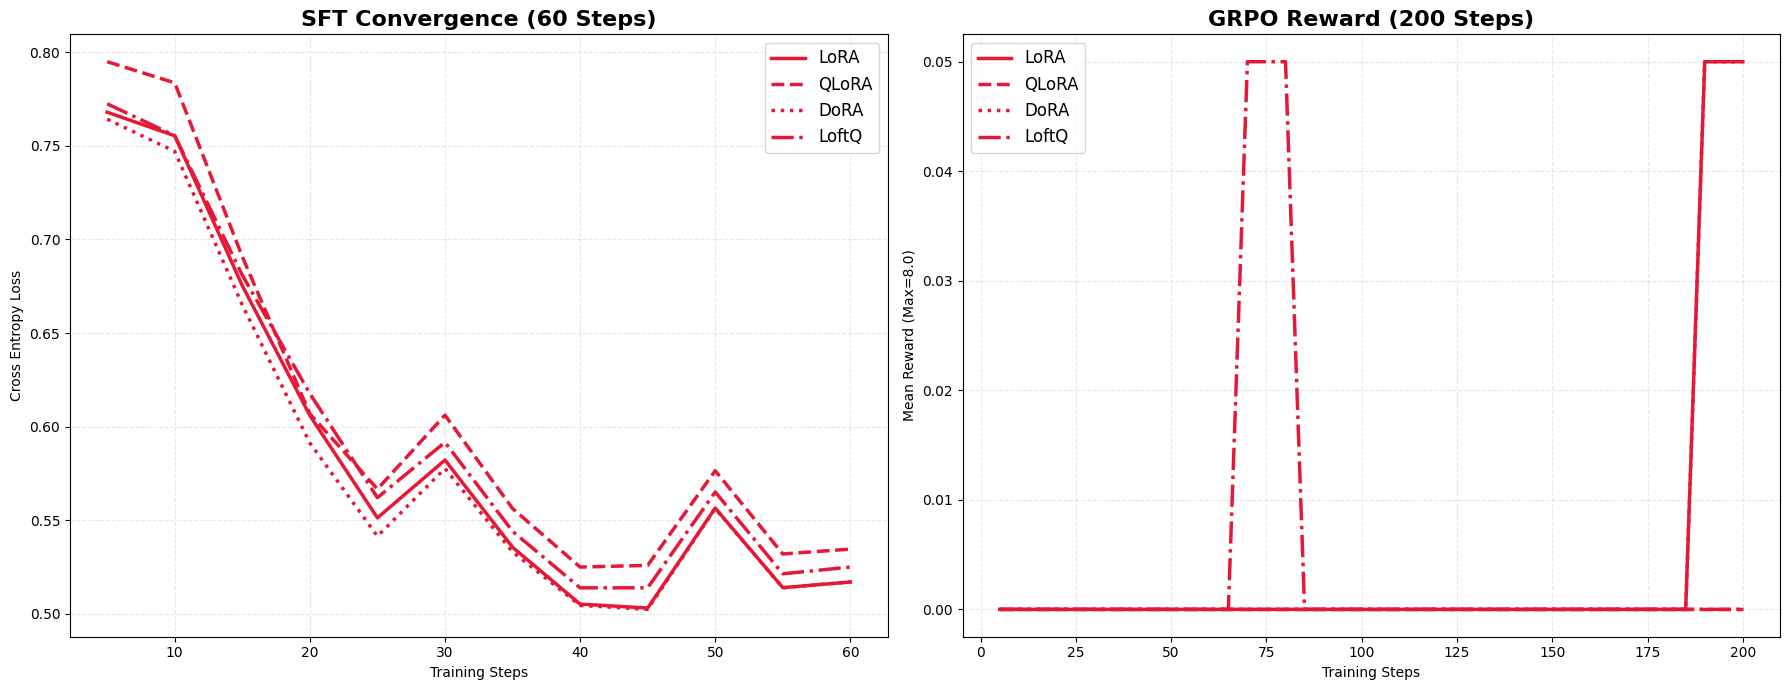

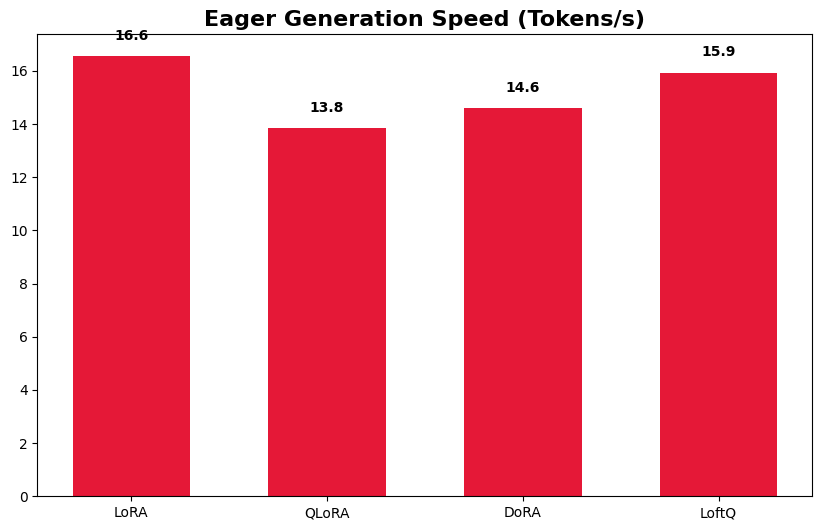

In [3]:

results = {name: run_scaled_variant(name, conf) for name, conf in ADAPTERS.items()}

print("\nGenerating High-Fidelity Plots...")

line_styles = ['-', '--', ':', '-.']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# SFT Loss
for i, (name, data) in enumerate(results.items()):
    steps = np.arange(1, len(data["sft_loss"]) + 1) * 5
    ax1.plot(steps, data["sft_loss"], label=name, color=BRAND_COLOR, linestyle=line_styles[i], linewidth=2.5)

ax1.set_title(f"SFT Convergence ({SFT_STEPS} Steps)", fontsize=16, fontweight='bold')
ax1.set_xlabel("Training Steps")
ax1.set_ylabel("Cross Entropy Loss")
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.legend(fontsize=12)

# GRPO Reward
for i, (name, data) in enumerate(results.items()):
    steps = np.arange(1, len(data["grpo_reward"]) + 1) * 5
    rewards = pd.Series(data["grpo_reward"]).rolling(3, min_periods=1).mean()
    ax2.plot(steps, rewards, label=name, color=BRAND_COLOR, linestyle=line_styles[i], linewidth=2.5)

ax2.set_title(f"GRPO Reward ({GRPO_STEPS} Steps)", fontsize=16, fontweight='bold')
ax2.set_xlabel("Training Steps")
ax2.set_ylabel("Mean Reward (Max=8.0)")
ax2.grid(True, linestyle='--', alpha=0.3)
ax2.legend(fontsize=12)

plt.tight_layout()
plt.savefig("tradeoff_high_fidelity.png", dpi=300)
plt.show()


plt.figure(figsize=(10, 6))
names = list(results.keys())
tps = [results[n]["tps"] for n in names]
bars = plt.bar(names, tps, color=BRAND_COLOR, width=0.6)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{height:.1f}', ha='center', va='bottom', fontweight='bold')

plt.title("Eager Generation Speed (Tokens/s)", fontsize=16, fontweight='bold')
plt.savefig("tradeoff_tps_final.png", dpi=300)
plt.show()

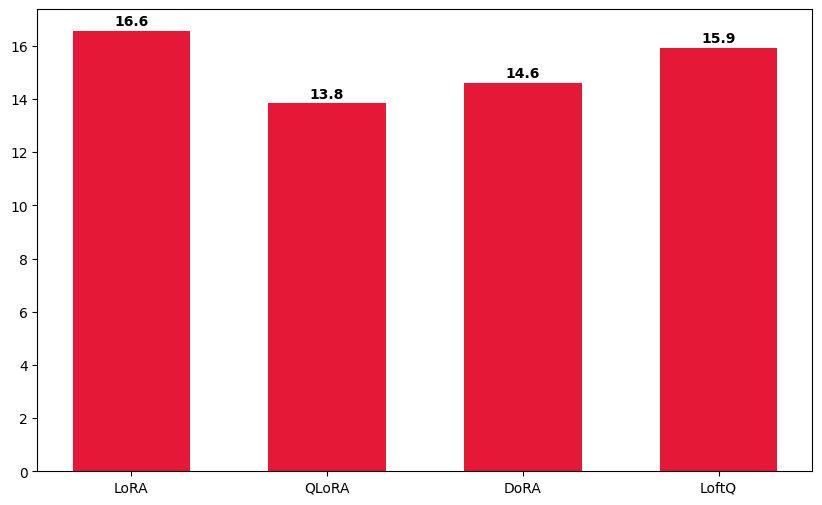

In [7]:
# Bar Chart
plt.figure(figsize=(10, 6))
names = list(results.keys())
tps = [results[n]["tps"] for n in names]
bars = plt.bar(names, tps, color=BRAND_COLOR, width=0.6)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1, f'{height:.1f}', ha='center', va='bottom', fontweight='bold')

#plt.title("Eager Generation Speed (Tokens/s)", fontsize=16, fontweight='bold')
plt.savefig("tradeoff_tps_final.png", dpi=300)
plt.show()


Generating High-Fidelity Plots...


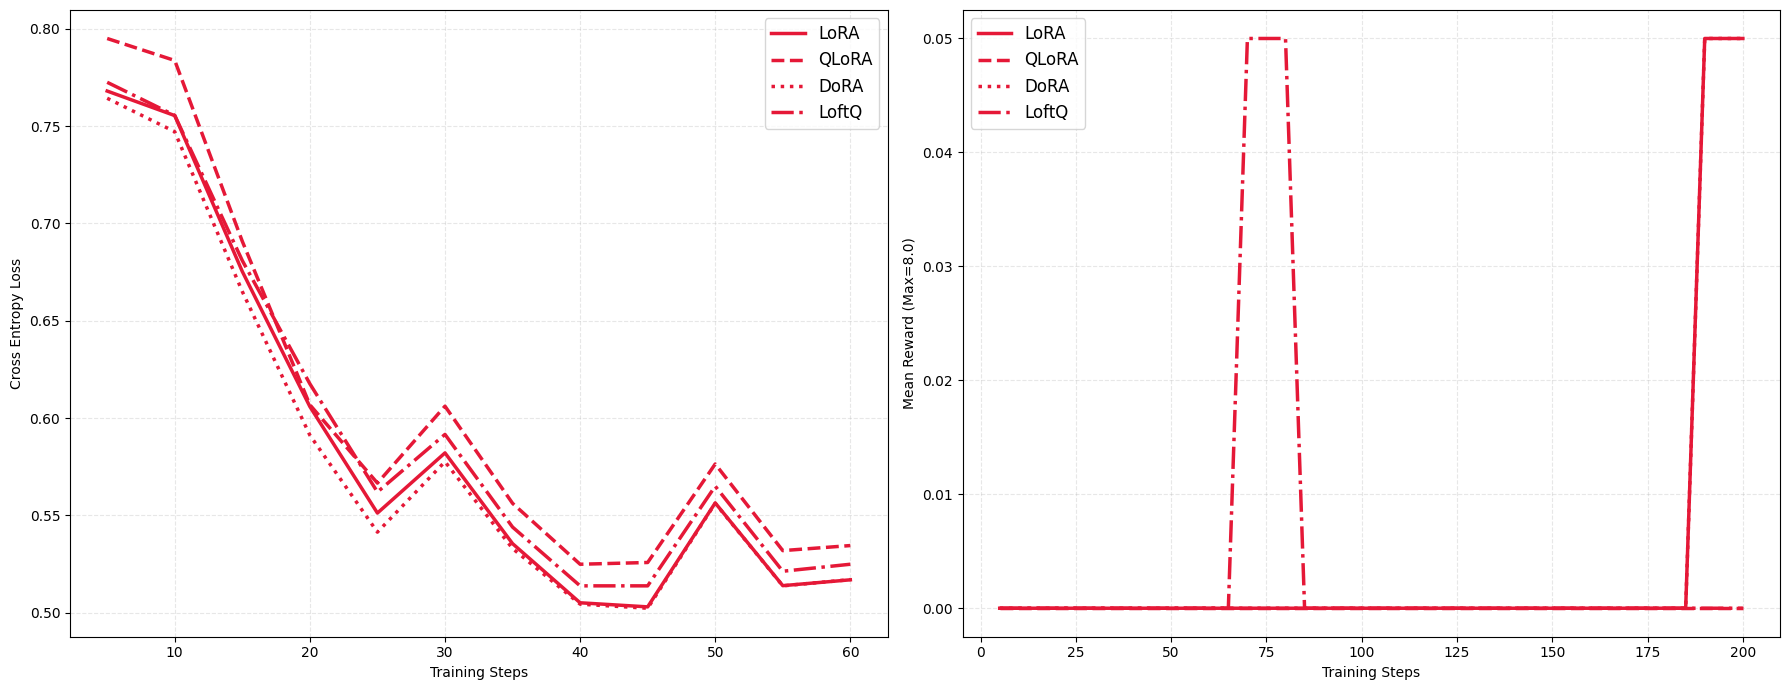

In [9]:
print("\nGenerating High-Fidelity Plots...")

line_styles = ['-', '--', ':', '-.']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: SFT Loss
for i, (name, data) in enumerate(results.items()):
    steps = np.arange(1, len(data["sft_loss"]) + 1) * 5
    ax1.plot(steps, data["sft_loss"], label=name, color=BRAND_COLOR, linestyle=line_styles[i], linewidth=2.5)

#ax1.set_title(f"SFT Convergence ({SFT_STEPS} Steps)", fontsize=16, fontweight='bold')
ax1.set_xlabel("Training Steps")
ax1.set_ylabel("Cross Entropy Loss")
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.legend(fontsize=12)

# Plot 2: GRPO Reward
for i, (name, data) in enumerate(results.items()):
    steps = np.arange(1, len(data["grpo_reward"]) + 1) * 5
    rewards = pd.Series(data["grpo_reward"]).rolling(3, min_periods=1).mean()
    ax2.plot(steps, rewards, label=name, color=BRAND_COLOR, linestyle=line_styles[i], linewidth=2.5)

#ax2.set_title(f"GRPO Reward ({GRPO_STEPS} Steps)", fontsize=16, fontweight='bold')
ax2.set_xlabel("Training Steps")
ax2.set_ylabel("Mean Reward (Max=8.0)")
ax2.grid(True, linestyle='--', alpha=0.3)
ax2.legend(fontsize=12)

plt.tight_layout()
plt.savefig("tradeoff_high_fidelity.png", dpi=300)
plt.show()